In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

In [15]:
ds = pd.read_csv("HospitalityEmployees.csv", parse_dates=["Date"], index_col="Date")

In [16]:
ds.head()

,Employees
Date,
1990-01-01,1064.5
1990-02-01,1074.5
1990-03-01,1090.0
1990-04-01,1097.4
1990-05-01,1108.7


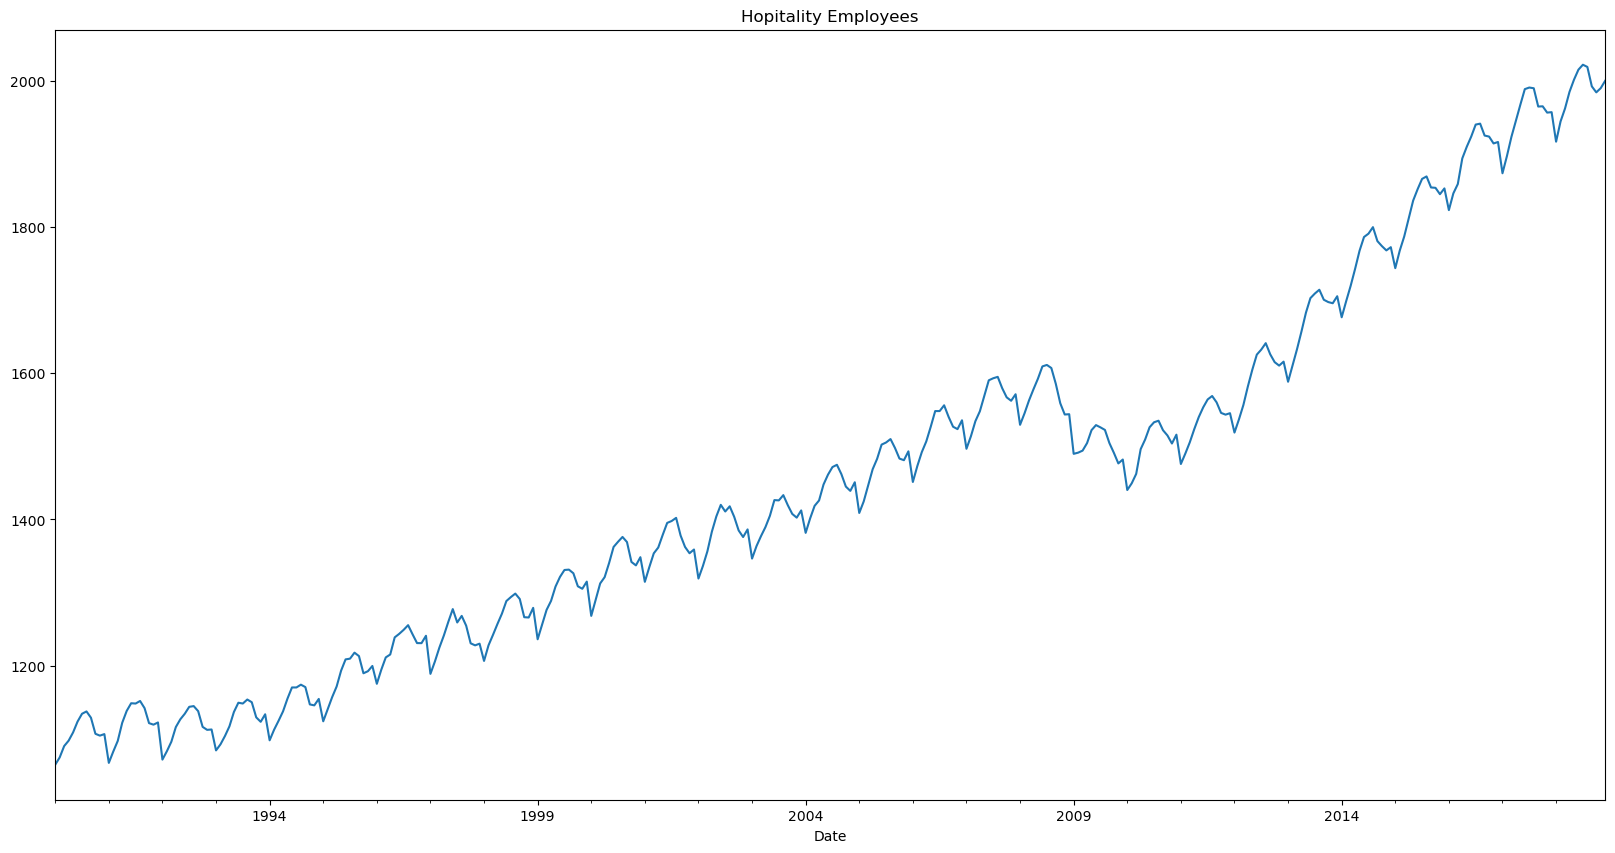

In [18]:
ds["Employees"].plot(figsize=(20,10))
plt.title("Hopitality Employees")
plt.show()

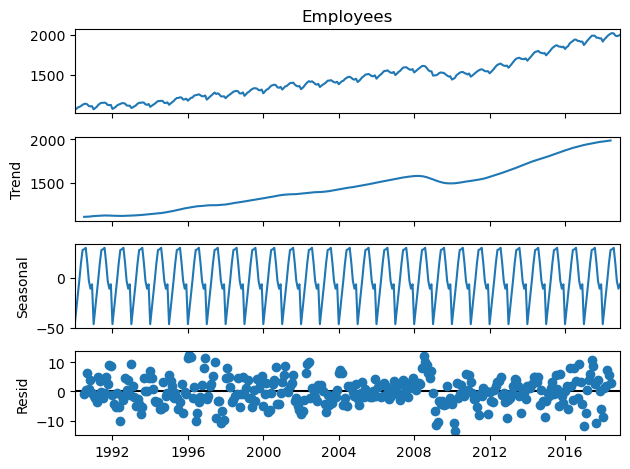

In [22]:
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(ds["Employees"], model="add")
result.plot()

In [23]:
import warnings
warnings.filterwarnings("ignore")

In [24]:
from statsmodels.tsa.arima.model import ARIMA

In [25]:
p = 5
d = 1
q = 0
model = ARIMA(ds, order=(p, d, q))
arimares = model.fit()

In [27]:
forecasthoriz = 10
forecast = arimares.forecast(steps=forecasthoriz)

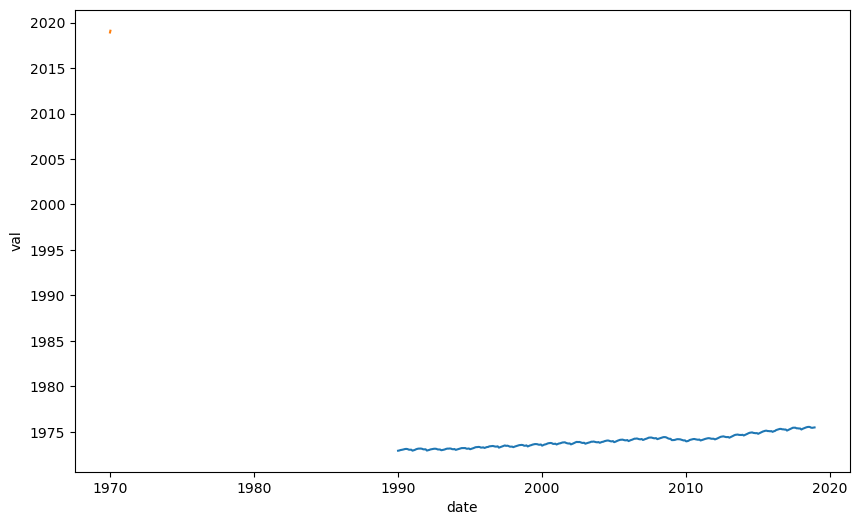

In [35]:
plt.figure(figsize=(10,6))
plt.plot(ds, label="obsv")
plt.plot(pd.date_range(start=ds.index[-1], periods=forecasthoriz + 1, freq="W"))
plt.xlabel("date")
plt.ylabel("val")
plt.show()